In [4]:
!pip install gensim
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns
import nltk

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

from gensim.models import Word2Vec

In [5]:
# ==========================================
# 1. SETUP
# ==========================================

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

stop_words = set(stopwords.words('english'))
stop_words.discard('not')
stop_words.discard('no')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [6]:

# ==========================================
# 2. LOAD DATA
# ==========================================

print("Loading dataset...")
df = pd.read_csv('amazonreviews.tsv', sep='\t')

print("Initial Shape:", df.shape)

df.dropna(inplace=True)
df.drop_duplicates(inplace=True)

print("Shape After Cleaning:", df.shape)

Loading dataset...
Initial Shape: (10000, 2)
Shape After Cleaning: (10000, 2)


In [7]:

# ==========================================
# 3. TEXT CLEANING
# ==========================================

def clean_text(text):
    text = text.lower()
    text = re.sub(r'<[^>]*>', '', text)
    text = re.sub(r'[^\w\s]', '', text)
    text = ' '.join(word for word in text.split() if word not in stop_words)
    return text

print("Cleaning text...")
df['cleaned_review'] = df['review'].apply(clean_text)

# Tokenization (for Word2Vec)
df['tokens'] = df['cleaned_review'].apply(word_tokenize)

Cleaning text...


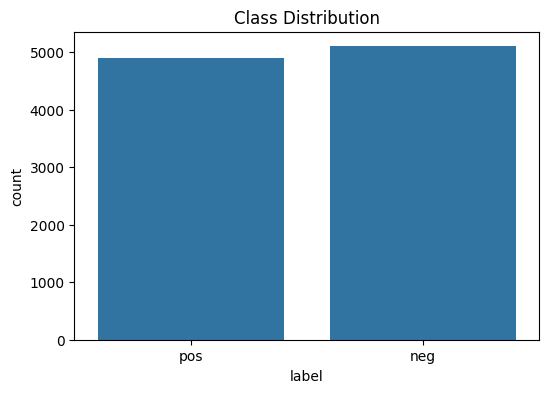

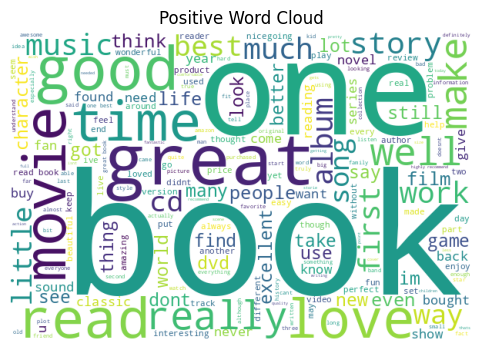

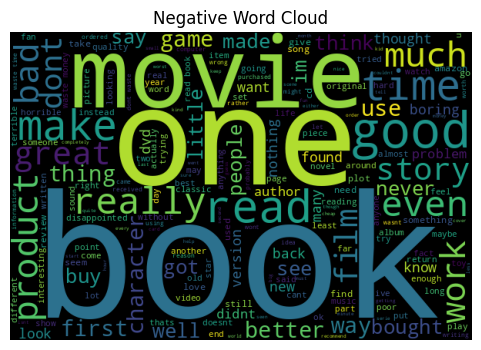

In [8]:
# ==========================================
# 4. EXPLORATORY DATA ANALYSIS
# ==========================================

plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df)
plt.title("Class Distribution")
plt.show()

pos_text = " ".join(df[df['label'] == 'pos']['cleaned_review'])
neg_text = " ".join(df[df['label'] == 'neg']['cleaned_review'])

plt.figure(figsize=(6,4))
WordCloud(width=600, height=400, background_color='white').generate(pos_text)
plt.imshow(WordCloud(width=600, height=400, background_color='white').generate(pos_text))
plt.title("Positive Word Cloud")
plt.axis("off")
plt.show()

plt.figure(figsize=(6,4))
plt.imshow(WordCloud(width=600, height=400, background_color='black').generate(neg_text))
plt.title("Negative Word Cloud")
plt.axis("off")
plt.show()

In [9]:
# ==========================================
# 5. FEATURE PREPARATION
# ==========================================

X = df['cleaned_review']
y = df['label']

# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=62, stratify=y
)


===== TF-IDF MODEL =====
TF-IDF CV Scores: [0.862  0.8705 0.865  0.8685 0.8595]
TF-IDF Mean CV Accuracy: 0.8651

TF-IDF Test Accuracy: 0.867

Classification Report:
               precision    recall  f1-score   support

         neg       0.87      0.87      0.87      1019
         pos       0.86      0.87      0.86       981

    accuracy                           0.87      2000
   macro avg       0.87      0.87      0.87      2000
weighted avg       0.87      0.87      0.87      2000



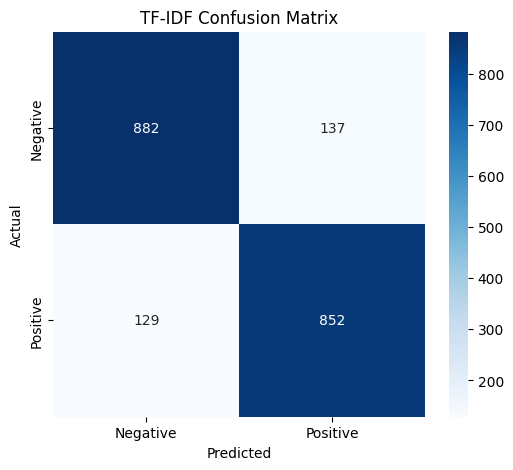

In [10]:
# ==========================================
# 6. TF-IDF MODEL
# ==========================================

print("\n===== TF-IDF MODEL =====")

tfidf_vectorizer = TfidfVectorizer(max_features=10000, ngram_range=(1,2))

X_tfidf_full = tfidf_vectorizer.fit_transform(X)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
tfidf_model = LinearSVC(random_state=82)

tfidf_cv_scores = cross_val_score(
    tfidf_model, X_tfidf_full, y, cv=cv, scoring='accuracy'
)

print("TF-IDF CV Scores:", tfidf_cv_scores)
print("TF-IDF Mean CV Accuracy:", np.mean(tfidf_cv_scores))

# Train on Train Split
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

tfidf_model.fit(X_train_tfidf, y_train)
tfidf_predictions = tfidf_model.predict(X_test_tfidf)

print("\nTF-IDF Test Accuracy:", accuracy_score(y_test, tfidf_predictions))
print("\nClassification Report:\n", classification_report(y_test, tfidf_predictions))

# Confusion Matrix
cm = confusion_matrix(y_test, tfidf_predictions, labels=['neg','pos'])
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative','Positive'],
            yticklabels=['Negative','Positive'])
plt.title("TF-IDF Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [11]:
# ==========================================
# 7. WORD2VEC MODEL
# ==========================================

print("\n===== WORD2VEC MODEL =====")

w2v_model = Word2Vec(
    sentences=df['tokens'],
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

def get_avg_w2v(tokens, model, vector_size):
    vectors = []
    for word in tokens:
        if word in model.wv:
            vectors.append(model.wv[word])
    if len(vectors) == 0:
        return np.zeros(vector_size)
    return np.mean(vectors, axis=0)

X_w2v = np.array([
    get_avg_w2v(tokens, w2v_model, 100)
    for tokens in df['tokens']
])

w2v_cv_scores = cross_val_score(
    LinearSVC(random_state=82),
    X_w2v,
    y,
    cv=cv,
    scoring='accuracy'
)

print("Word2Vec CV Scores:", w2v_cv_scores)
print("Word2Vec Mean CV Accuracy:", np.mean(w2v_cv_scores))

# Train/Test for Word2Vec
X_train_w2v = np.array([
    get_avg_w2v(word_tokenize(text), w2v_model, 100)
    for text in X_train
])

X_test_w2v = np.array([
    get_avg_w2v(word_tokenize(text), w2v_model, 100)
    for text in X_test
])

w2v_classifier = LinearSVC(random_state=82)
w2v_classifier.fit(X_train_w2v, y_train)
w2v_predictions = w2v_classifier.predict(X_test_w2v)

print("\nWord2Vec Test Accuracy:", accuracy_score(y_test, w2v_predictions))
print("\nClassification Report:\n", classification_report(y_test, w2v_predictions))






===== WORD2VEC MODEL =====
Word2Vec CV Scores: [0.782  0.7735 0.779  0.7875 0.794 ]
Word2Vec Mean CV Accuracy: 0.7832

Word2Vec Test Accuracy: 0.7815

Classification Report:
               precision    recall  f1-score   support

         neg       0.78      0.79      0.79      1019
         pos       0.78      0.77      0.78       981

    accuracy                           0.78      2000
   macro avg       0.78      0.78      0.78      2000
weighted avg       0.78      0.78      0.78      2000



In [12]:
# ==========================================
# 8. MODEL COMPARISON
# ==========================================

print("\n===== MODEL COMPARISON =====")
print(f"TF-IDF Mean CV Accuracy: {np.mean(tfidf_cv_scores):.4f}")
print(f"Word2Vec Mean CV Accuracy: {np.mean(w2v_cv_scores):.4f}")


===== MODEL COMPARISON =====
TF-IDF Mean CV Accuracy: 0.8651
Word2Vec Mean CV Accuracy: 0.7832


In [13]:
# ==========================================
# 9. INFERENCE FUNCTION
# ==========================================

def predict_sentiment_tfidf(text):
    cleaned = clean_text(text)
    vec = tfidf_vectorizer.transform([cleaned])
    pred = tfidf_model.predict(vec)[0]
    return "Positive" if pred == 'pos' else "Negative"

def predict_sentiment_w2v(text):
    cleaned = clean_text(text)
    tokens = word_tokenize(cleaned)
    vec = get_avg_w2v(tokens, w2v_model, 100).reshape(1,-1)
    pred = w2v_classifier.predict(vec)[0]
    return "Positive" if pred == 'pos' else "Negative"

# Test Samples
sample1 = "The battery died after one hour. Completely useless."
sample2 = "Amazing product! Exceeded expectations and arrived early."

print("\nSample 1 TF-IDF:", predict_sentiment_tfidf(sample1))
print("Sample 1 Word2Vec:", predict_sentiment_w2v(sample1))

print("\nSample 2 TF-IDF:", predict_sentiment_tfidf(sample2))
print("Sample 2 Word2Vec:", predict_sentiment_w2v(sample2))


Sample 1 TF-IDF: Negative
Sample 1 Word2Vec: Negative

Sample 2 TF-IDF: Positive
Sample 2 Word2Vec: Positive
